### **LABORATORIO #5 ELECTRÓNICA: Respuesta en frecuencia**

---
---

In [1]:
using Plots, LaTeXStrings, CSV, DataFrames, Colors
const path = @__DIR__
theme(:dark)


---
---
---

#### **CIRCUITO 1: Filtro pasa bajas**

**DATOS:**

- $C = 0.1 \ \lceil \mu F \rceil$
- $f_c = 1000 \ \lceil Hz \rceil$

$$
I = \frac{V_{in}}{Z_t} = \frac{V_{in}}{R + \frac{1}{j\omega C}}
$$
$$
V_C = V_{out} = I*Z_C = \frac{V_{in}}{R + \frac{1}{j\omega C}}\frac{1}{j\omega C}
$$
$$
H = \frac{V_{out}}{V_{in}} = \frac{V_C}{V_{in}} = \frac{\frac{V_{in}}{R + \frac{1}{j\omega C}}\frac{1}{j\omega C}}{V_{in}} = \frac{1}{Rj\omega C +1}
$$
$$
|H|^2 = \frac{1}{1 + (R\omega C)^2}
$$

para frecuencia de corte $|H_c|^2 = 1/2$. Entonces, 

$$
|H_c|^2 = 1/2 = \frac{1}{1+R^2(2\pi)^2f_c^2C^2} \implies R^2(2\pi)^2f_c^2C^2 = 1 \implies R = \frac{1}{2\pi f_cC}
$$
Remplazando valores conocidos, 
$$
R =  \frac{1}{2\pi \cdot 1000 \cdot 10^{-7}} \ \lceil \Omega \rceil 
$$
$$
\boxed{\therefore R = 1591.55 \ \lceil \Omega \rceil \approx 1.6 \ \lceil k\Omega \rceil}
$$

Tomaremos el valor aproximado de $1.6 \ k\Omega$ para facilidad experimental.

Adicionalmente, tenemos
$$
\boxed{|H(f)| = \frac{1}{\sqrt{1+(2\pi R f C)^2}}}
$$

---

**Diseño del circuito en Altium:**

---

In [2]:
H1_exp = [0.958, 0.963, 0.968, 0.909, 0.684, 0.068, -0.001] #Anotamos los datos directamente como V_c/V_s
f1_exp = [0.1, 1, 10, 100, 1000, 10000, 100000] #Rango de frecuencias analizadas en el laboratorio

R1 = 1.6e3 #valor de la resistencia para una f_c ≈ 1000Hz
C1 = 0.1e-6 #Capacitancia propuesta

f1 = range(0.1, 1e6, length = 100000) #rango de frecuencias para gráfica teórica
H1 = 1 ./ sqrt.(1 .+ (2pi .* R1 .* f .* C1) .^ 2) # Expresión teórica para la función de transferencia


#GRAFICAS

plot(f1, H1, xscale = :log10, 
    ylabel = L"Abs transfer \ function \ - \ |H(f)|", xlabel = L"frecuency \  - \ f \ \ \lceil \log(Hz) \rceil", label = L"|H(f)| \ theo",
    lw = 2, ticks = [0.0, 1, 1e2, 1e3, 1e4, 1e5, 1e6], legendfontsize = 10)

plot!(f1_exp, H1_exp, 
    marker = :circle, 
    label = L"|H(f)| \ exp", lw = 2)

vline!([1/(2pi*1.6e3*0.1e-6)], ls = :dash, label = L"f_c \approx 994.7 \ Hz", color = :gold)
scatter!([1/(2pi*1.6e3*0.1e-6)], [1/sqrt(2)], label = false, color = :gold, marker = :square)

UndefVarError: UndefVarError: `f` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

---
---
---

### **CIRCUITO 2: filtro pasa altas**

**DATOS:**

- $C = 0.1 \ \lceil \mu F \rceil$
- $f_c = 100 \ \lceil Hz \rceil$

$$
I = \frac{V_{in}}{Z_t} = \frac{V_{in}}{R + \frac{1}{j\omega C}}
$$
$$
V_R = V_{out} = I*R = \frac{V_{in}R}{R + \frac{1}{j\omega C}}
$$
$$
H = \frac{V_{out}}{V_{in}} = \frac{V_C}{V_{in}} = \frac{\frac{V_{in}R}{R + \frac{1}{j\omega C}}}{V_{in}} = \frac{Rj\omega C}{Rj\omega C +1}
$$
$$
|H|^2 = \frac{(R\omega C)^2}{1 + (R\omega C)^2}
$$

para frecuencia de corte $|H_c|^2 = 1/2$. Entonces, 

$$
|H_c|^2 = 1/2 = \frac{(R\omega C)^2}{1 + (R\omega C)^2} \implies R^2(2\pi)^2f_c^2C^2 = 1 \implies R = \frac{1}{2\pi f_cC}
$$
Remplazando valores conocidos, 
$$
R =  \frac{1}{2\pi \cdot 100 \cdot 10^{-7}} \ \lceil \Omega \rceil 
$$
$$
\boxed{\therefore R = 15915.5 \ \lceil \Omega \rceil \approx 16 \ \lceil k\Omega \rceil}
$$

Tomaremos el valor aproximado de $16 \ k\Omega$ para facilidad experimental.

Adicionalmente, tenemos
$$
\boxed{|H(f)| = \frac{2\pi R f C}{\sqrt{1+(2\pi R f C)^2}}}

---

**Diseño del circuito en Altium:**

---

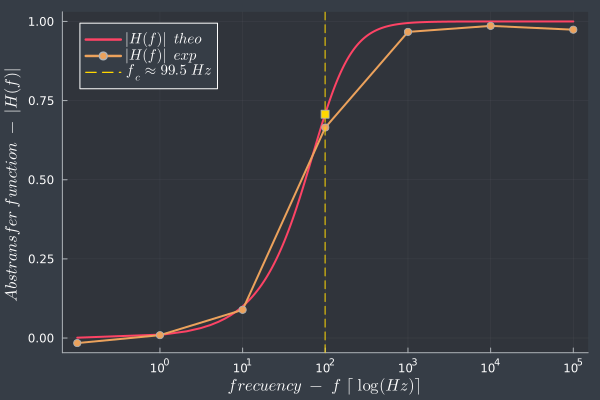

In [3]:
H2_exp = [-0.016, 0.009, 0.089, 0.665, 0.967, 0.986, 0.974] #Anotamos los datos directamente como V_R/V_s
f2_exp = copy(f1_exp) #Mismas frecuencias evaluadas

R2 = 16e3 #Valor de R encontrado para mantener la frecuencia de corte alrededor de los 100 Hz
C2 = copy(C1) #Mantenemos el mismo capacitor. Para no tener que estar cambiando en el montaje experimental

f2 = range(0.1, 1e5, length = 100000) #rango de frecuencias para grafica teórica
H2 = (2pi*R2*C2 .* f2) ./ sqrt.(1 .+ (2pi*R2*C2 .* f2) .^ 2) # Expresión teórica para la function de tranferencia

#GRAFICAS
plot(f2, H2, 
    ylabel = L"Abs transfer \ function \ - \ |H(f)|", xlabel = L"frecuency \  - \ f \ \ \lceil \log(Hz) \rceil", label = L"|H(f)| \ theo",
    xscale = :log10, xticks = [0.0, 1, 10, 1e2, 1e3, 1e4, 1e5], legendfontsize = 10, legend = :topleft, lw = 2)
    
plot!(f2_exp, H2_exp, 
    marker = :circle, 
    label = L"|H(f)| \ exp", lw = 2)

vline!([1/(2pi*R2*C2)], label = L"f_c \approx 99.5 \ Hz", ls = :dash, color = :gold)

scatter!([1/(2pi*R2*C2)], [1/sqrt(2)], label = false, color = :gold, marker = :square)

---
---
---

### **CIRCUITO #3: filtro pasa bandas**

**DATOS:**

- $f_0 = 500 \ \lceil Hz \rceil$
- $\beta = 100 \ \lceil Hz \rceil$

$$
I = \frac{V_{in}}{Z_t} = \frac{V_{in}}{R + j\omega L + \frac{1}{j\omega C}}
$$
$$
V_{out} = V_R = I*R = \frac{R*V_{in}}{R + j\omega L + \frac{1}{j\omega C}}
$$
$$
H = \frac{V_{out}}{V_{in}} = \frac{R}{R + j\omega L + \frac{1}{j\omega C}} = \frac{Rj\omega C}{Rj\omega C - \omega^2LC + 1}
$$
$$
\implies |H|^2 = \frac{(R\omega C)^2}{(R\omega C)^2 + (1 - \omega^2 LC)^2}
$$

Con los datos de la frecuencia centras y el ancho de banda podemos armar el siguiente sistema de ecuaciones

$$
f_0 = 500 \ \lceil Hz \rceil = \frac{1}{2\pi \sqrt{LC}} \implies C = \frac{1}{(1000\pi)^2L}
$$
$$
\beta = 100 \ \lceil Hz \rceil =  \frac{R}{2\pi L} \implies R = 200\pi L
$$

Si tomamos $L = 100 mH$, entonces 
$$
\boxed{R = 62.83 \ \lceil \Omega \rceil \approx  60 \ \lceil \Omega \rceil}
$$

En este caso armaremos la resistencia con dos de $100 \Omega$ en paralelo y una de $10 \Omega$ en serie. Finalmente, 
$$
\boxed{C = 1.01 \times 10^{-6} \ \lceil F \rceil \approx 1 \ \lceil \mu F \rceil}
$$
Así,

$$
|H| = \frac{2\pi RC f}{\sqrt{(2\pi RC f)^2 + (1 - 4 \pi^2 LC f^2)^2}}
$$

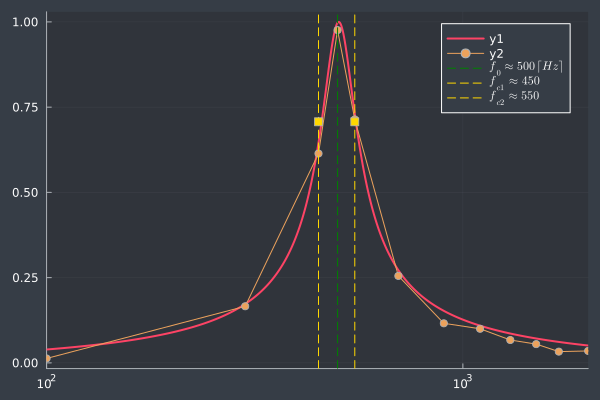

In [4]:
R3 = 60 #Ohmios (Ω)
C3 = 1e-6 #Faradios (F)
L3 = 0.1 # Henrios (H)

f3_exp = [100, 300, 450, 500, 550, 700, 900, 1100, 1300, 1500, 1700, 2000]
H3_exp = [0.013, 0.166, 0.614, 0.976, 0.714, 0.255, 0.116, 0.1, 0.067, 0.055, 0.033, 0.035]

f3 = range(100, 2000, length = 1000)
H3 = (2pi*R3*C3 .* f3) ./ sqrt.((2pi*R3*C3 .* f3) .^ 2 .+ (1 .- 4*pi^2*L3*C3 .* f3 .^ 2) .^ 2)

plot(f3, H3, xscale = :log10, lw = 2, xlims = (100, 2000))

plot!(f3_exp, H3_exp, marker = :circle)

vline!([500], label = L"f_0 \approx 500 \ \lceil Hz \rceil", color = :green, ls = :dash)

vline!([450 550], label = [L"f_{c1} \approx 450" L"f_{c2} \approx 550"], color = :gold, ls = :dash)

scatter!([450 550], [1/sqrt(2)], label = false, color = :gold, marker = :square)


---
---
---

### **CIRUCITO 4: filtro rechaza altas**

**DATOS:**

- $f_{c1} = 100 \ \lceil Hz \rceil$
- $f_{c2} = 1000 \ \lceil Hz \rceil$

$$
\beta = f_{c2} - f_{c1} = 900 = \frac{R}{2\pi L} \implies R = 1800\pi L
$$
Tomando $L = 0.1 \ \lceil H \rceil$, obtenemos 
$$
R = 180\pi \ \lceil \Omega \rceil \approx 560 \ \lceil \Omega \rceil
$$
$$
f_0 = \sqrt{f_{c2}\cdot f_{c1}} = \sqrt{10^5} = \frac{1}{2\pi \sqrt{LC}} \implies C = \frac{1}{4\pi^2\cdot 0.1 \cdot 10^5} \approx 2.53 \ \lceil \mu F \rceil
$$
Dicha capacitancia se logra con un capacitor de $2.2 \ \mu F$ en paralelo con uno de $330 \ nF$



In [5]:
frecs = [100, 300, 450, 500, 550, 700, 900, 1100, 1300, 1500, 1700, 2000]
Hs = (2pi*R3*C3 .* frecs) ./ sqrt.((2pi*R3*C3 .* frecs) .^ 2 .+ (1 .- 4*pi^2*L3*C3 .* frecs .^ 2) .^ 2)
ran = rand(length(frecs))*0.05
Amps = Hs .- ran
show(round.(Amps, digits = 3)')

adjoint([0.038, 0.163, 0.628, 0.992, 0.702, 0.266, 0.116, 0.072, 0.073, 0.057, 0.041, 0.042])